<a href="https://colab.research.google.com/github/sila85/production_ml_demo/blob/main/U-data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q ml-100k.zip

In [ ]:
import os

print(os.listdir("/content/ml-100k"))

['u4.test', 'ub.test', 'u3.base', 'ua.base', 'u.user', 'u2.base', 'u.genre', 'u1.base', 'allbut.pl', 'mku.sh', 'u.info', 'u.data', 'u4.base', 'u1.test', 'README', 'u.occupation', 'ub.base', 'u5.base', 'ua.test', 'u5.test', 'u3.test', 'u2.test', 'u.item']


In [ ]:
import pandas as pd
import numpy as np

ratings = pd.read_csv(
    "/content/ml-100k/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

print("Dataset loaded successfully!")
print("Shape:", ratings.shape)

ratings.head()

Dataset loaded successfully!
Shape: (100000, 4)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(train))
print("Testing records:", len(test))

Training records: 80000
Testing records: 20000


In [ ]:
R_train = train.pivot_table(
    index="user_id",
    columns="item_id",
    values="rating"
)

print("User-item matrix shape:", R_train.shape)
R_train.head()

User-item matrix shape: (943, 1653)


item_id,1,2,3,4,5,6,7,8,9,10,...,1668,1670,1671,1672,1673,1676,1678,1679,1680,1681
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,3.0,4.0,NaN,3.0,NaN,4.0,NaN,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate each user's average rating
user_means = R_train.mean(axis=1)

# Center ratings around each user's mean
R_centered = R_train.sub(user_means, axis=0)

# Calculate item-item adjusted cosine similarity
item_similarity = cosine_similarity(
    R_centered.T.fillna(0)
)

# Convert to DataFrame
item_similarity = pd.DataFrame(
    item_similarity,
    index=R_train.columns,
    columns=R_train.columns
)

print("Similarity matrix shape:", item_similarity.shape)

Similarity matrix shape: (1653, 1653)


In [ ]:
def predict_rating(user_id, item_id, k=20, shrinkage=0):

    # If user is unknown
    if user_id not in R_train.index:
        return train["rating"].mean()

    # Ratings given by this user
    user_ratings = R_train.loc[user_id].dropna()

    # If item is unknown
    if item_id not in item_similarity.index:
        return user_ratings.mean()

    # Similarities between target item and items rated by user
    sims = item_similarity.loc[
        item_id,
        user_ratings.index
    ].copy()

    # Remove target item if present
    if item_id in sims.index:
        sims = sims.drop(item_id)

    # Apply shrinkage
    if shrinkage > 0:

        counts = []

        for j in sims.index:

            n = R_train[
                [item_id, j]
            ].dropna().shape[0]

            counts.append(n)

        counts = pd.Series(
            counts,
            index=sims.index
        )

        sims = sims * counts / (counts + shrinkage)

    # Select top-k by absolute similarity
    top_items = (
        sims.abs()
        .sort_values(ascending=False)
        .head(k)
        .index
    )

    sims = sims.loc[top_items]

    ratings_used = user_ratings.loc[top_items]

    # User's mean rating
    user_mean = user_ratings.mean()

    # Prediction
    numerator = (
        sims * (ratings_used - user_mean)
    ).sum()

    denominator = sims.abs().sum()

    if denominator == 0:
        return user_mean

    prediction = user_mean + numerator / denominator

    # Keep prediction within MovieLens rating range
    return np.clip(prediction, 1, 5)

In [ ]:
k_values = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50]

results_k = []

for k in k_values:

    print(f"Calculating k = {k}...")

    predictions = []
    actuals = []

    for row in test.itertuples():

        pred = predict_rating(
            row.user_id,
            row.item_id,
            k=k,
            shrinkage=0
        )

        predictions.append(pred)
        actuals.append(row.rating)

    rmse = np.sqrt(
        np.mean(
            (np.array(actuals) - np.array(predictions)) ** 2
        )
    )

    results_k.append([k, rmse])

results_k = pd.DataFrame(
    results_k,
    columns=["k", "RMSE"]
)

results_k

Calculating k = 1...
Calculating k = 2...
Calculating k = 3...
Calculating k = 5...
Calculating k = 10...
Calculating k = 15...
Calculating k = 20...
Calculating k = 30...
Calculating k = 40...
Calculating k = 50...


,k,RMSE
0,1,1.206008
1,2,1.066200
2,3,1.017499
3,5,0.978436
4,10,0.948906
5,15,0.940018
6,20,0.937441
7,30,0.935911
8,40,0.936644
9,50,0.937334


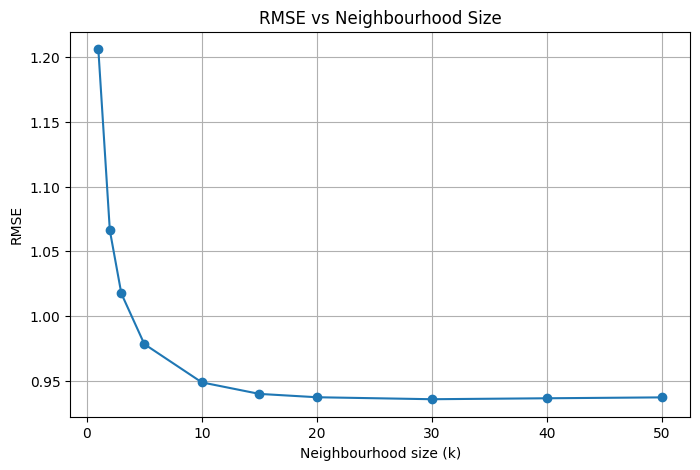

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_k["k"],
    results_k["RMSE"],
    marker="o"
)

plt.xlabel("Neighbourhood size (k)")
plt.ylabel("RMSE")
plt.title("RMSE vs Neighbourhood Size")
plt.grid(True)

plt.show()

In [ ]:
best_k_row = results_k.loc[
    results_k["RMSE"].idxmin()
]

print("Best k:", best_k_row["k"])
print("Best RMSE:", best_k_row["RMSE"])

Best k: 30.0
Best RMSE: 0.9359112042406866


In [ ]:
best_k = int(best_k_row["k"])

shrinkage_values = [0, 1, 5, 10, 20, 50, 100]

results_shrinkage = []

for lam in shrinkage_values:

    print(f"Calculating shrinkage = {lam}...")

    predictions = []
    actuals = []

    for row in test.itertuples():

        pred = predict_rating(
            row.user_id,
            row.item_id,
            k=best_k,
            shrinkage=lam
        )

        predictions.append(pred)
        actuals.append(row.rating)

    rmse = np.sqrt(
        np.mean(
            (np.array(actuals) - np.array(predictions)) ** 2
        )
    )

    results_shrinkage.append([lam, rmse])

results_shrinkage = pd.DataFrame(
    results_shrinkage,
    columns=["Shrinkage", "RMSE"]
)

results_shrinkage

Calculating shrinkage = 0...
Calculating shrinkage = 1...
Calculating shrinkage = 5...


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_shrinkage["Shrinkage"],
    results_shrinkage["RMSE"],
    marker="o"
)

plt.xlabel("Shrinkage parameter λ")
plt.ylabel("RMSE")
plt.title("RMSE vs Shrinkage")
plt.grid(True)

plt.show()